In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [6]:
orders = pd.read_csv('/content/olist_orders_dataset (ORDER ID).csv')
order_items = pd.read_csv('/content/olist_order_items_dataset (MAIN DATA).csv')
products = pd.read_csv('/content/olist_products_dataset (PRODUK ID).csv')

In [7]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)


In [8]:
print(orders.columns)
print(order_items.columns)
print(products.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


In [9]:
data = pd.merge(order_items, orders, on='order_id')

In [10]:
print(data.shape)

(112650, 14)


In [11]:
data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00


In [12]:
data = pd.merge(data, products, on='product_id')

In [13]:
print(data.shape)

(112650, 22)


In [14]:
data = data[['product_id',
             'order_purchase_timestamp',
             'price',
             'product_category_name']]

In [15]:
data.columns = ['product_id', 'tanggal', 'price', 'category']

In [16]:
data.head()

,product_id,tanggal,price,category
0,4244733e06e7ecb4970a6e2683c13e61,2017-09-13 08:59:02,58.90,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,2017-04-26 10:53:06,239.90,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,2018-01-14 14:33:31,199.00,moveis_decoracao
3,7634da152a4610f1595efa32f14722fc,2018-08-08 10:00:35,12.99,perfumaria
4,ac6c3623068f30de03045865e4e10089,2017-02-04 13:57:51,199.90,ferramentas_jardim


In [17]:
print(data.isnull().sum())

product_id       0
tanggal          0
price            0
category      1603
dtype: int64


In [18]:
data = data.dropna()

In [19]:
print(data.shape)
print(data.isnull().sum())

(111047, 4)
product_id    0
tanggal       0
price         0
category      0
dtype: int64


In [20]:
data['tanggal'] = pd.to_datetime(data['tanggal'])

In [21]:
top_products = data['product_id'].value_counts().head(10)

print(top_products)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64


In [22]:
top_product_ids = top_products.index

data[data['product_id'].isin(top_product_ids)][['product_id', 'category']].drop_duplicates()

,product_id,category
12,99a4788cb24856965c36a24e339b6058,cama_mesa_banho
13,368c6c730842d78016ad823897a372db,ferramentas_jardim
114,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes
126,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim
141,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios
258,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao
380,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim
508,422879e10f46682990de24d770e7f83d,ferramentas_jardim
982,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios
1816,154e7e31ebfa092203795c972e5804a6,beleza_saude


In [23]:
product_data = data[data['product_id'] == 'aca2eb7d00ea1a7b8ebd4e68314663af']

In [24]:
product_data = product_data.sort_values('tanggal')

In [25]:
print(product_data.shape)

(527, 4)


In [ ]:
print(sales.shape)

(117, 1)


In [26]:
product_data[['tanggal', 'price']].head(15)

,tanggal,price
11393,2017-07-25 10:50:22,75.0
55353,2017-07-28 14:20:19,75.0
40977,2017-07-28 15:56:14,75.0
64256,2017-07-29 13:22:44,75.0
64255,2017-07-29 13:22:44,75.0
43968,2017-08-01 13:11:47,75.0
43970,2017-08-01 13:11:47,75.0
43969,2017-08-01 13:11:47,75.0
49237,2017-08-02 10:38:47,75.0
3412,2017-08-03 11:47:07,75.0


In [27]:
weekly_sales = product_data.groupby('tanggal').size()

In [28]:
weekly_sales = weekly_sales.resample('W').sum()

In [29]:
weekly_sales = weekly_sales.reset_index()
weekly_sales.columns = ['tanggal', 'qty']

In [30]:
print(weekly_sales.shape)
weekly_sales.head(20)

(56, 2)


,tanggal,qty
0,2017-07-30,5
1,2017-08-06,13
2,2017-08-13,0
3,2017-08-20,0
4,2017-08-27,0
5,2017-09-03,0
6,2017-09-10,0
7,2017-09-17,0
8,2017-09-24,0
9,2017-10-01,0


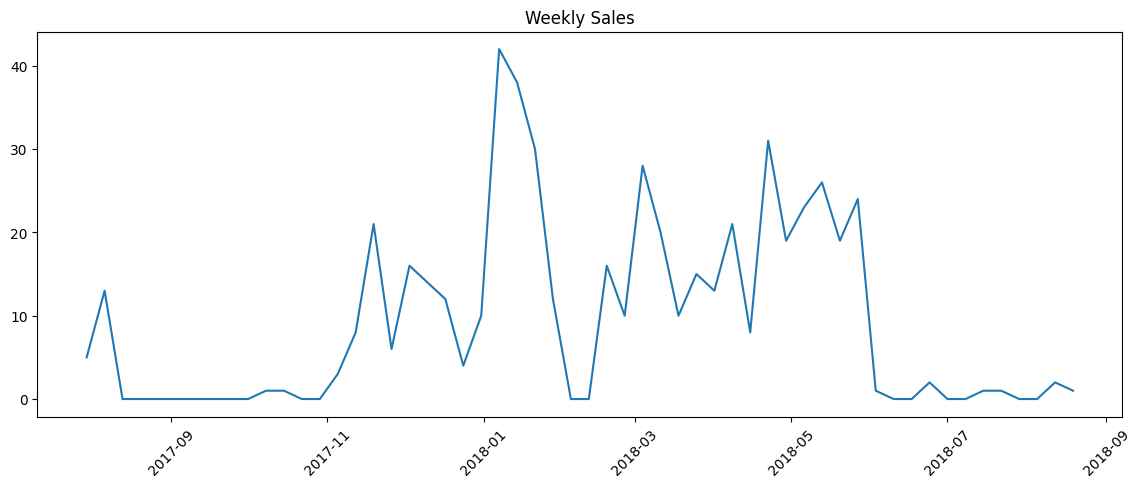

In [31]:
plt.figure(figsize=(14,5))
plt.plot(weekly_sales['tanggal'], weekly_sales['qty'])
plt.title('Weekly Sales')
plt.xticks(rotation=45)
plt.show()

In [40]:
sales = weekly_sales[['qty']]

In [41]:
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales)

In [42]:
print(sales_scaled[:10])

[[0.11904762]
 [0.30952381]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]


In [72]:
def create_sequences(data, window_size):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

In [73]:
window_size = 12

In [74]:
X, y = create_sequences(sales_scaled, window_size)

In [75]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (44, 12, 1)
y shape: (44, 1)


In [76]:
print(X[0])
print(y[0])

[[0.11904762]
 [0.30952381]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.02380952]
 [0.02380952]]
[0.]


In [82]:
inputs = Input(shape=(12,1))

x = LSTM(64)(inputs)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)

outputs = Dense(1)(x)

model = Model(inputs, outputs)

In [83]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [84]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [86]:
history = model.fit(
    X, y,
    epochs=80,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - loss: 0.1488 - val_loss: 0.0062
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0950 - val_loss: 0.0354
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0721 - val_loss: 0.0789
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0822 - val_loss: 0.0725
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0733 - val_loss: 0.0452
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0733 - val_loss: 0.0283
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0686 - val_loss: 0.0200
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0815 - val_loss: 0.0292
Epoch 9/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0690 - val_loss: 0.0393


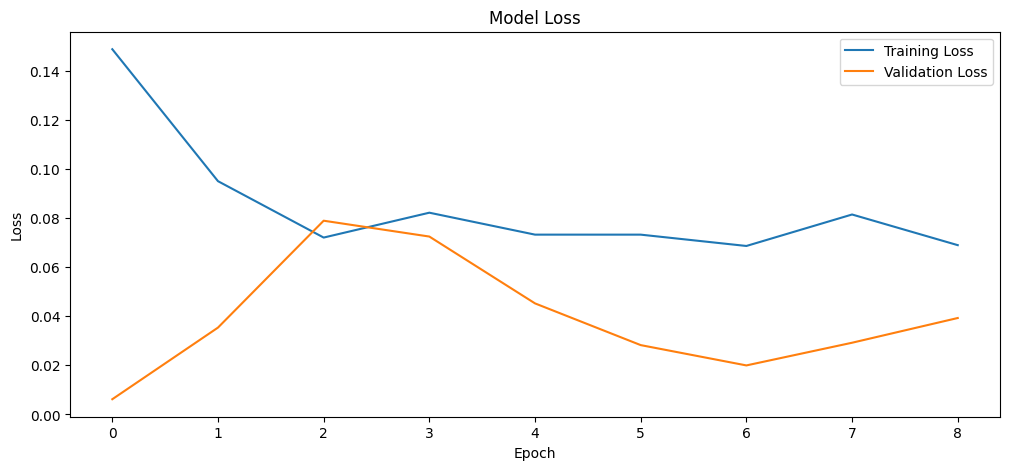

In [87]:
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [88]:
predictions = model.predict(X)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


In [89]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y)

In [90]:
for i in range(15):
    print(f"Aktual: {actual[i][0]:.2f} | Prediksi: {predictions[i][0]:.2f}") #masih nggak akurat, jgn pakai dulu

Aktual: 0.00 | Prediksi: 2.24
Aktual: 0.00 | Prediksi: 2.16
Aktual: 3.00 | Prediksi: 2.04
Aktual: 8.00 | Prediksi: 2.17
Aktual: 21.00 | Prediksi: 2.54
Aktual: 6.00 | Prediksi: 3.52
Aktual: 16.00 | Prediksi: 3.67
Aktual: 14.00 | Prediksi: 4.28
Aktual: 12.00 | Prediksi: 4.72
Aktual: 4.00 | Prediksi: 5.01
Aktual: 10.00 | Prediksi: 4.85
Aktual: 42.00 | Prediksi: 4.97
Aktual: 38.00 | Prediksi: 6.61
Aktual: 30.00 | Prediksi: 7.94
Aktual: 12.00 | Prediksi: 8.77


In [91]:
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9.112140075726943
RMSE: 12.2915707179053


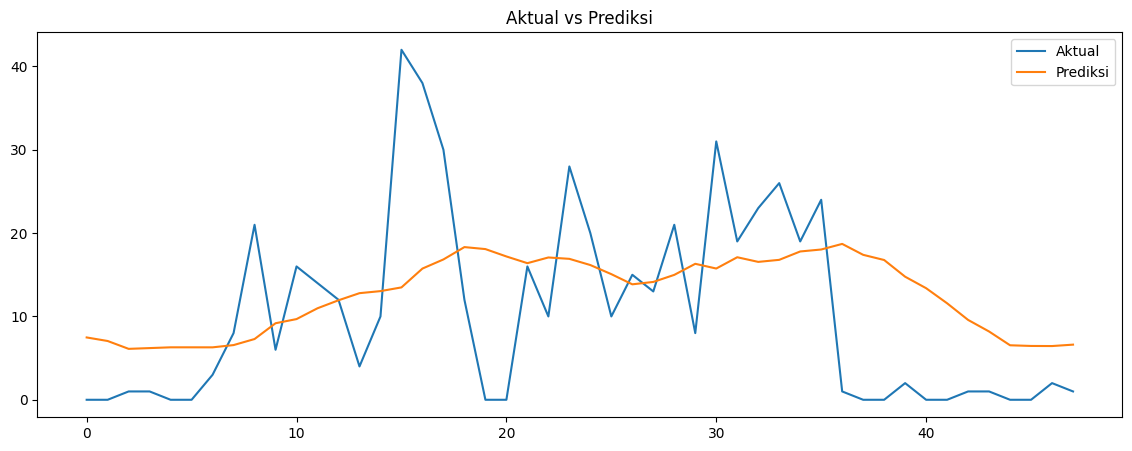

In [56]:
plt.figure(figsize=(14,5))
plt.plot(actual, label='Aktual')
plt.plot(predictions, label='Prediksi')
plt.title('Aktual vs Prediksi')
plt.legend()
plt.show()

In [92]:
model.save('sistemrekomendasi1_moneytor.keras')